### **Bag of n_grams: Exercise**

- Fake news refers to misinformation or disinformation in the country which is spread through word of mouth and more recently through digital communication such as What's app messages, social media posts, etc.

- Fake news spreads faster than Real news and creates problems and fear among groups and in society.

- We are going to address these problems using classical NLP techniques and going to classify whether a given message/ text is **Real or Fake Message**.

- You will use a Bag of n-grams to pre-process the text and apply different classification algorithms.

- Sklearn CountVectorizer has the inbuilt implementations for Bag of Words.


### **About Data: Fake News Detection**

Credits: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset


- This data consists of two columns.
        - Text
        - label
- Text is the statements or messages regarding a particular event/situation.

- label feature tells whether the given Text is Fake or Real.

- As there are only 2 classes, this problem comes under the **Binary Classification.**


In [2]:
#import pandas library
import pandas as pd
#read the dataset with name "Fake_Real_Data.csv" and store it in a variable df
df_train = pd.read_csv('../csv_files/emotion-labels-train.csv')
df_test = pd.read_csv('../csv_files/emotion-labels-test.csv')

#print the shape of dataframe
df_train.shape
df_test.shape
#print top 5 rows
df_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [3]:
#check the distribution of labels 
df_train.label.value_counts()

label
fear       1147
anger       857
joy         823
sadness     786
Name: count, dtype: int64

In [4]:
#Add the new column "label_num" which gives a unique number to each of these labels 
samples = 786

df_fear = df_train[df_train.label == "fear"].sample(samples, random_state=2020)
df_anger = df_train[df_train.label == "anger"].sample(samples, random_state=2020)
df_joy = df_train[df_train.label == "joy"].sample(samples, random_state=2020)
df_sadness = df_train[df_train.label == "sadness"].sample(samples, random_state=2020)

df = pd.concat([df_fear, df_anger, df_joy, df_sadness], axis=0)
df.head()

,text,label
1539,@EurekaForbes U got to b kidding me. Anu from ...,fear
828,@mgcsartwork I nearly started crying and havin...,fear
881,"I start work tmrw yall, i'm nervous lol",fear
1102,Democracy doesn't work\n#mob #mentality #mass ...,fear
1827,How in the world did Nicole beat Paul?!?! #ter...,fear


In [5]:
df['label_num'] = df.label.map({
  'fear': 0,
  'anger': 1,
  'joy': 2,
  'sadness': 3
})

df.tail()

,text,label,label_num
2918,im so gloomy today,sadness,3
3534,No one wants to win the wild card because you ...,sadness,3
3457,If you sober better roll another Dutch or if u...,sadness,3
3150,Ill say it again. If I was a Black man Id be a...,sadness,3
3219,@TouchPH The solution is to punish the crimin...,sadness,3


### **Modelling without Pre-processing Text data**

In [6]:
#import train-test-split from sklearn 
from sklearn.model_selection import train_test_split

#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
X_train, X_test, y_train, y_test = train_test_split(df.text, df.label_num, test_size=0.2, random_state=2020, stratify=df.label_num)


In [7]:
#print the shapes of X_train and X_test
X_test.shape


(629,)

**Attempt 1** :

1. using sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, bigram, and trigrams.
- use KNN as the classifier with n_neighbors of 10 and metric as 'euclidean' distance.
- print the classification report.


In [8]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

clf = Pipeline([
  ('vectorizer', CountVectorizer()),
  ('mnb', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.24      0.31       158
           1       0.30      0.63      0.41       157
           2       0.51      0.30      0.38       157
           3       0.39      0.30      0.34       157

    accuracy                           0.37       629
   macro avg       0.41      0.37      0.36       629
weighted avg       0.41      0.37      0.36       629



**Attempt 2** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, bigram, and trigrams.
- use **KNN** as the classifier with n_neighbors of 10 and metric as 'cosine' distance.
- print the classification report.


In [9]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

clf = Pipeline([
  ('vectorizer', CountVectorizer()),
  ('mnb', KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.43      0.46      0.44       158
           1       0.44      0.43      0.43       157
           2       0.53      0.50      0.51       157
           3       0.41      0.42      0.42       157

    accuracy                           0.45       629
   macro avg       0.45      0.45      0.45       629
weighted avg       0.45      0.45      0.45       629




**Attempt 3** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with only trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [10]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

clf = Pipeline([
  ('vectorizer', CountVectorizer()),
  ('random_forest', RandomForestClassifier())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82       158
           1       0.82      0.86      0.84       157
           2       0.96      0.85      0.90       157
           3       0.84      0.81      0.82       157

    accuracy                           0.84       629
   macro avg       0.85      0.84      0.85       629
weighted avg       0.85      0.84      0.85       629




**Attempt 4** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with both unigram and bigrams.
- use **Multinomial Naive Bayes** as the classifier with an alpha value of 0.75.
- print the classification report.


In [ ]:
#1. create a pipeline object
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB

clf = Pipeline([
  ('vectorizer', CountVectorizer()),
  ('random_forest', MultinomialNB(alpha=0.75))
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.69      0.75       158
           1       0.82      0.80      0.81       157
           2       0.86      0.82      0.84       157
           3       0.69      0.85      0.76       157

    accuracy                           0.79       629
   macro avg       0.80      0.79      0.79       629
weighted avg       0.80      0.79      0.79       629



In [21]:
y_pred[:40]

array([2, 0, 3, 1, 3, 0, 2, 0, 0, 0, 1, 1, 1, 3, 3, 1, 0, 1, 0, 1, 2, 0,
       3, 2, 0, 0, 2, 3, 2, 0, 2, 2, 3, 2, 2, 1, 0, 0, 3, 1])

In [ ]:
y_test[:40]

431     2
925     0
3339    3
2329    1
2853    3
1478    0
744     2
2632    1
1026    0
1147    0
1997    1
2772    1
2197    1
3334    3
859     0
2103    1
891     0
2627    1
1906    0
2673    1
332     2
1043    0
3454    3
1989    1
1097    0
1335    0
676     2
3068    3
319     2
1429    0
180     2
809     2
3403    3
132     2
1211    0
2602    1
2889    3
1194    0
2938    3
1849    0
Name: label_num, dtype: int64

<h3>Use text pre-processing to remove stop words, punctuations and apply lemmatization </h3>

In [23]:
#use this utility function to get the preprocessed text data
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

filtered_tokens = []
def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)
        

In [25]:
# create a new column "preprocessed_txt" and use the utility function above to get the clean data
df['preprocessed_text'] = df.text.apply(preprocess)
df.head()
# this will take some time, please be patient


,text,label,label_num,preprocessed_text
1539,@EurekaForbes U got to b kidding me. Anu from ...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
828,@mgcsartwork I nearly started crying and havin...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
881,"I start work tmrw yall, i'm nervous lol",fear,0,@eurekaforbe u get b kid Anu firm respond se...
1102,Democracy doesn't work\n#mob #mentality #mass ...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
1827,How in the world did Nicole beat Paul?!?! #ter...,fear,0,@eurekaforbe u get b kid Anu firm respond se...


In [26]:
#print the top 5 rows
df.head()

,text,label,label_num,preprocessed_text
1539,@EurekaForbes U got to b kidding me. Anu from ...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
828,@mgcsartwork I nearly started crying and havin...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
881,"I start work tmrw yall, i'm nervous lol",fear,0,@eurekaforbe u get b kid Anu firm respond se...
1102,Democracy doesn't work\n#mob #mentality #mass ...,fear,0,@eurekaforbe u get b kid Anu firm respond se...
1827,How in the world did Nicole beat Paul?!?! #ter...,fear,0,@eurekaforbe u get b kid Anu firm respond se...


**Build a model with pre processed text**

In [27]:
#Do the 'train-test' splitting with test size of 20% with random state of 2022 and stratify sampling too
from sklearn.model_selection import train_test_split

#Note: Make sure to use only the "preprocessed_txt" column for splitting
X_train, X_test, y_train, y_test = train_test_split(df.preprocessed_text, df.label_num, test_size=0.2, random_state=2023, stratify=df.label_num)



**Let's check the scores with our best model till now**
- Random Forest

**Attempt1** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with only trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [28]:
#1. create a pipeline object
clf = Pipeline([
  ('vectorizer', CountVectorizer(ngram_range=(3,3))), 
  ('rf', RandomForestClassifier())
])


#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       157
           1       1.00      0.99      0.99       157
           2       0.98      1.00      0.99       157
           3       1.00      0.99      1.00       158

    accuracy                           1.00       629
   macro avg       1.00      1.00      1.00       629
weighted avg       1.00      1.00      1.00       629



**Attempt2** :

1. using the sklearn pipeline module create a classification pipeline to classify the Data.

**Note:**
- using CountVectorizer with unigram, Bigram, and trigrams.
- use **RandomForest** as the classifier.
- print the classification report.


In [30]:
#1. create a pipeline object
clf = Pipeline([
  ('vectorizer', CountVectorizer(ngram_range=(1,3))), 
  ('rf', RandomForestClassifier())
])


#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       157
           1       1.00      0.99      0.99       157
           2       0.98      1.00      0.99       157
           3       1.00      0.99      1.00       158

    accuracy                           1.00       629
   macro avg       1.00      1.00      1.00       629
weighted avg       1.00      1.00      1.00       629



In [32]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

Text(95.72222222222221, 0.5, 'Truthy values')

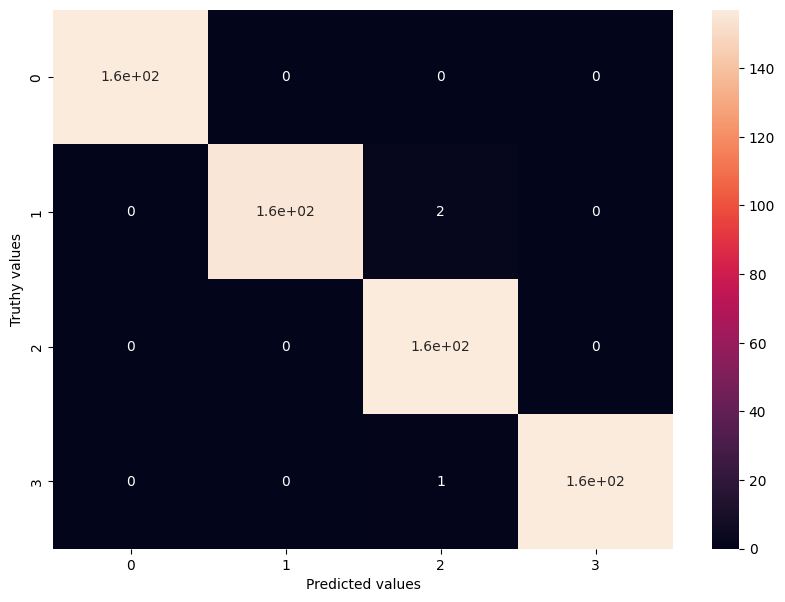

In [31]:
import seaborn as sn
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted values")
plt.ylabel("Truthy values")

## **Please write down Final Observations**


## [**Solution**](./bag_of_n_grams_exercise_solutions.ipynb)